In [2]:
# FIFA WORLD CUP 2026 - ANÁLISIS DE RENDIMIENTO DE JUGADORES
# Celda 1: Importar librerías y cargar datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset
df = pd.read_csv('fifa_world_cup_2026_player_performance.csv')

print("✅ Dataset cargado correctamente")
print(f"Shape: {df.shape}")
print(f"\nColumnas ({len(df.columns)}):")
print(df.columns.tolist())

✅ Dataset cargado correctamente
Shape: (54600, 75)

Columnas (75):
['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'deceler

In [3]:
# Celda 2: Exploración y limpieza
print("=== INFORMACIÓN GENERAL ===")
print(f"Total jugadores únicos: {df['player_name'].nunique()}")
print(f"Total partidos únicos: {df['match_id'].nunique()}")
print(f"Total selecciones: {df['nationality'].nunique()}")
print(f"Etapas del torneo: {df['tournament_stage'].unique()}")

print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

# Limpiar fecha
df['match_date'] = pd.to_datetime(df['match_date'])

print("\n✅ Limpieza completada!")
df.head()

=== INFORMACIÓN GENERAL ===
Total jugadores únicos: 1245
Total partidos únicos: 1050
Total selecciones: 48
Etapas del torneo: ['Group Stage' 'Round of 32' 'Round of 16' 'Quarter Finals' 'Semi Finals'
 'Third Place Match' 'Final']

=== VALORES NULOS ===
Series([], dtype: int64)

=== TIPOS DE DATOS ===
player_id                    object
player_name                  object
age                           int64
nationality                  object
team                         object
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object

✅ Limpieza completada!


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


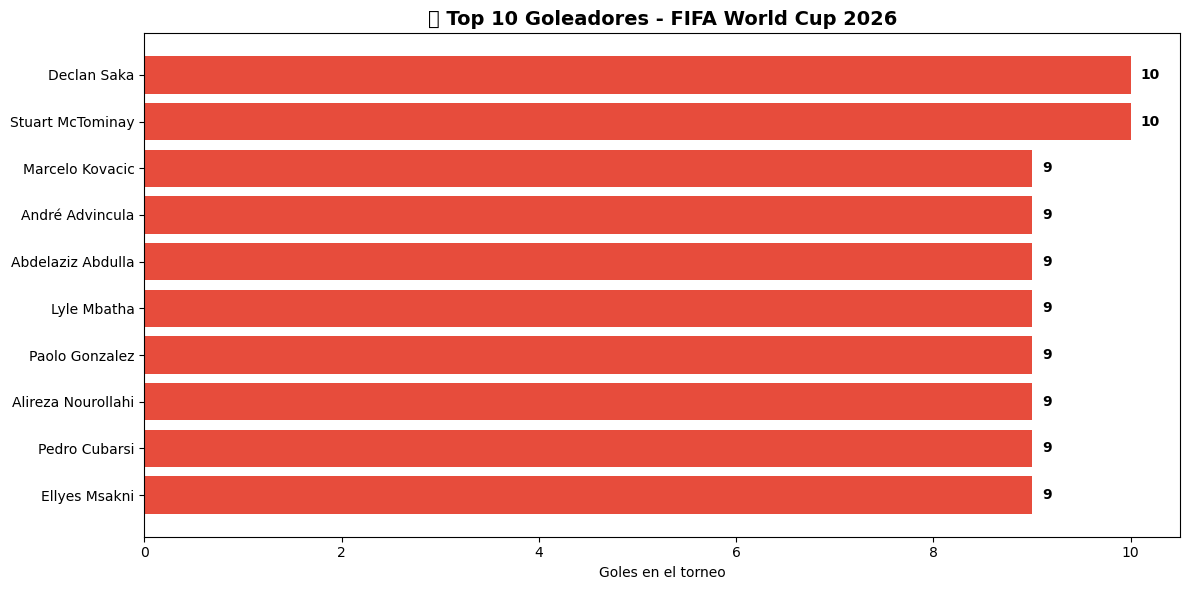

✅ Gráfico guardado!


In [4]:
# GRÁFICO 1: Top 10 goleadores
top_goleadores = df.groupby('player_name')['total_goals_tournament'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_goleadores.index, top_goleadores.values, color='#e74c3c')
plt.xlabel('Goles en el torneo')
plt.title('⚽ Top 10 Goleadores - FIFA World Cup 2026', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_goleadores.values):
    plt.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             str(int(val)), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('top10_goleadores_mundial.png', dpi=150)
plt.show()
print("✅ Gráfico guardado!")

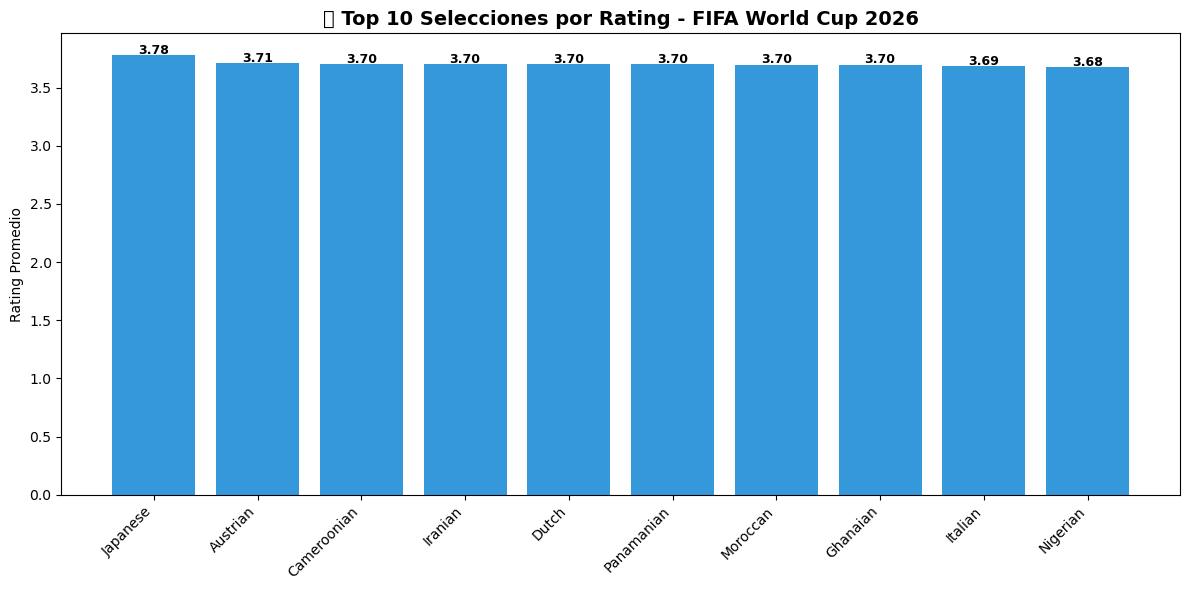

✅ Gráfico guardado!


In [5]:
# GRÁFICO 2: Top 10 selecciones por rating promedio
top_selecciones = df.groupby('nationality')['tournament_rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
bars = plt.bar(top_selecciones.index, top_selecciones.values, color='#3498db')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Rating Promedio')
plt.title('🏆 Top 10 Selecciones por Rating - FIFA World Cup 2026', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_selecciones.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.2f}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('top10_selecciones_rating.png', dpi=150)
plt.show()
print("✅ Gráfico guardado!")

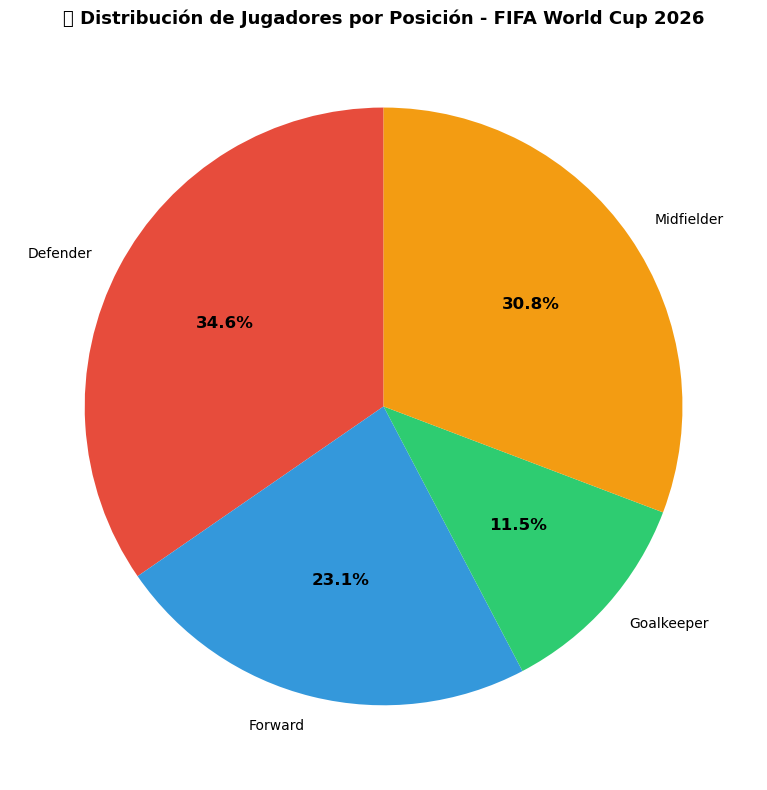

✅ Gráfico guardado!


In [6]:
# GRÁFICO 3: Distribución de jugadores por posición
posiciones = df.groupby('position')['player_name'].nunique()

plt.figure(figsize=(8,8))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
wedges, texts, autotexts = plt.pie(posiciones.values,
                                    labels=posiciones.index,
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90)
for text in autotexts:
    text.set_fontweight('bold')
    text.set_fontsize(12)
plt.title('👥 Distribución de Jugadores por Posición - FIFA World Cup 2026', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_posiciones.png', dpi=150)
plt.show()
print("✅ Gráfico guardado!")

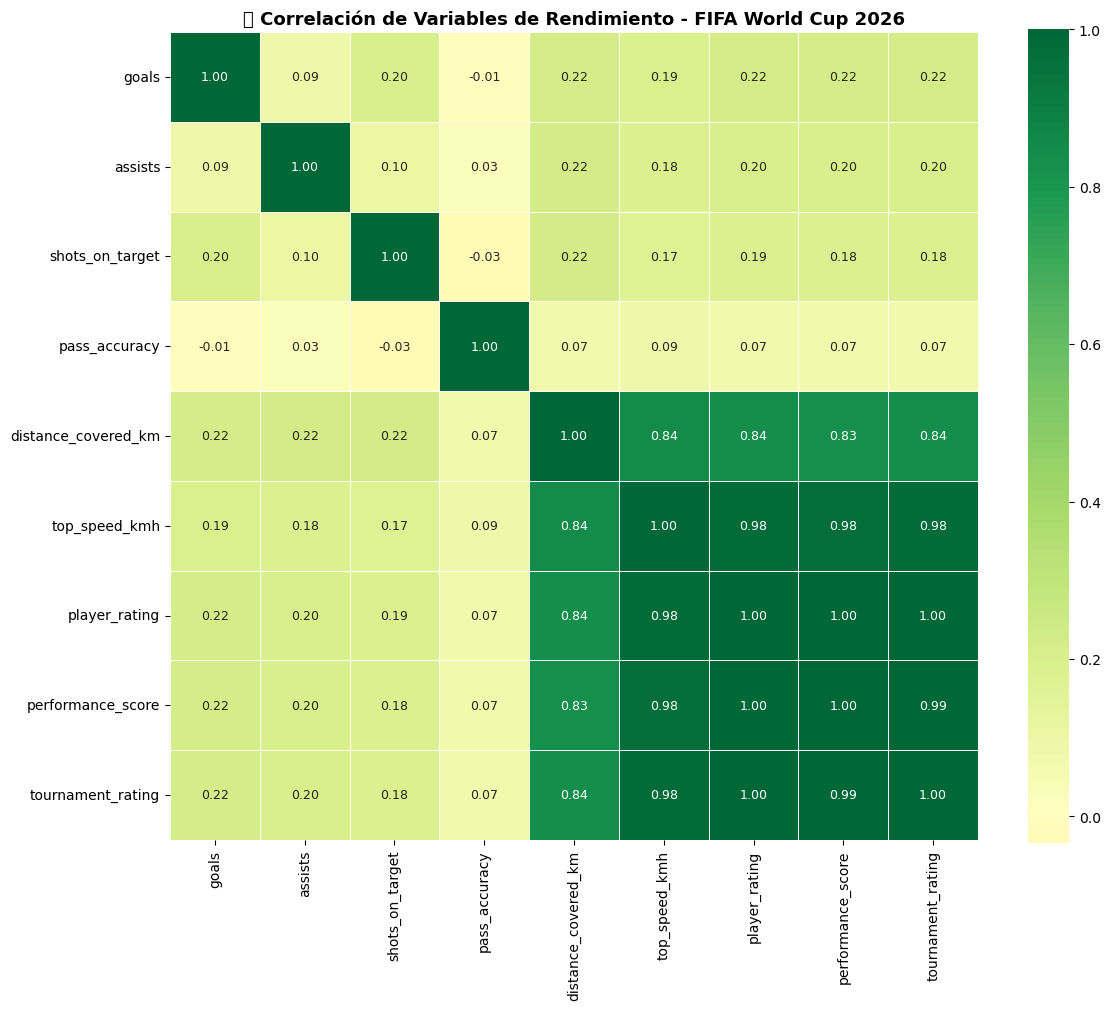

✅ Gráfico guardado!


In [7]:
# GRÁFICO 4: Heatmap de correlaciones de rendimiento
plt.figure(figsize=(12,10))
cols = ['goals', 'assists', 'shots_on_target', 'pass_accuracy', 
        'distance_covered_km', 'top_speed_kmh', 'player_rating',
        'performance_score', 'tournament_rating']
correlacion = df[cols].corr()

sns.heatmap(correlacion, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('🔥 Correlación de Variables de Rendimiento - FIFA World Cup 2026', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_rendimiento.png', dpi=150)
plt.show()
print("✅ Gráfico guardado!")

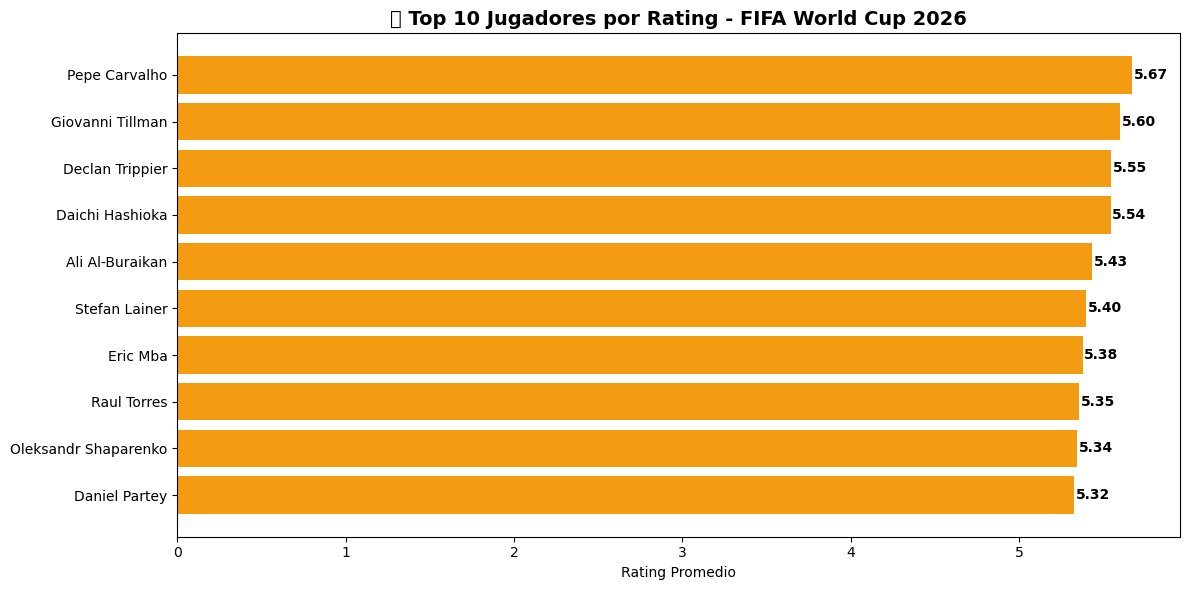

✅ Gráfico guardado!


In [8]:
# GRÁFICO 5: Top 10 jugadores por rating del torneo
top_jugadores = df.groupby('player_name')['tournament_rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_jugadores.index, top_jugadores.values, color='#f39c12')
plt.xlabel('Rating Promedio')
plt.title('⭐ Top 10 Jugadores por Rating - FIFA World Cup 2026', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_jugadores.values):
    plt.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
             f'{val:.2f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('top10_jugadores_rating.png', dpi=150)
plt.show()
print("✅ Gráfico guardado!")

In [ ]:
# Exportar datos limpios para SQL, Excel, Power BI y Tableau
df.to_csv('fifa_wc_2026_limpio.csv', index=False)
df.to_excel('fifa_wc_2026_limpio.xlsx', index=False)

# Crear base de datos SQL
conn = sqlite3.connect('fifa_wc_2026.db')
df.to_sql('player_performance', conn, if_exists='replace', index=False)
conn.close()

print("✅ Archivos exportados!")
print(f"Total registros: {len(df):,}")
print(f"Jugadores únicos: {df['player_name'].nunique():,}")
print(f"Selecciones: {df['nationality'].nunique()}")